In [1]:
import functools
import os
import sys
import traceback
from typing import Dict, Literal, Optional, Tuple

import cfp
import scanpy as sc
import numpy as np
import functools
from ott.solvers import utils as solver_utils
import optax
from omegaconf import OmegaConf
from typing import NamedTuple, Any
import hydra
import wandb
import anndata as ad
import h5py
import pandas as pd
import pickle
import cellflow

/home/icb/dominik.klein/mambaforge/envs/cellflow/lib/python3.12/site-packages/optuna/study/_optimize.py:29: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from optuna import progress_bar as pbar_module
/home/icb/dominik.klein/mambaforge/envs/cellflow/lib/python3.12/site-packages/anndata/utils.py:429: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/home/icb/dominik.klein/mambaforge/envs/cellflow/lib/python3.12/site-packages/anndata/utils.py:429: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  warnings.warn(msg, FutureWarning)
/home/icb/dominik.klein/mambaforge/envs/cellflow/lib/python3.12/site-packages/anndata/utils.py:429: FutureWarning: Importing read_hdf from `anndata` is deprecated. Import anndata.io.read_hdf instead.
  warnings.warn(msg, FutureWa

In [2]:
embedding_dir = "/lustre/groups/ml01/workspace/ot_perturbation/models/cellflow/embeddings_from_tahoe"

def get_embeddings(type: str):
    if type == "closest_cell_line":
        with open(os.path.join(embedding_dir, "sci_cl_cell_line.pkl"), "rb") as f:
            embedding_dict = pickle.load(f)
            
    elif type == "direct_embedding":
        with open(os.path.join(embedding_dir, "sci_emb.pkl"), "rb") as f:
            embedding_dict = pickle.load(f)
    elif type == "concatenated_drug_embeddings":
        with open(os.path.join(embedding_dir, "sci_drug_concatenated_from_tahoe.pkl"), "rb") as f:
            embedding_dict = pickle.load(f)
    else:
        raise ValueError
    return embedding_dict


In [3]:
split = 5
adata_train_path = f"/lustre/groups/ml01/workspace/ot_perturbation/data/sciplex/adata_train_{split}.h5ad"
adata_test_path = f"/lustre/groups/ml01/workspace/ot_perturbation/data/sciplex/adata_test_{split}.h5ad"
adata_ood_path = f"/lustre/groups/ml01/workspace/ot_perturbation/data/sciplex/adata_ood_{split}.h5ad"
adata_train = sc.read_h5ad(adata_train_path)
adata_test = sc.read_h5ad(adata_test_path)
adata_ood = sc.read_h5ad(adata_ood_path)




In [4]:
adata_train.obs["cell_line_drug"] = adata_train.obs["cell_line"].astype("str") + "_" + adata_train.obs["drug"].astype("str")
adata_ood.obs["cell_line_drug"] = adata_ood.obs["cell_line"].astype("str") + "_" + adata_ood.obs["drug"].astype("str")


In [21]:
emb_type = "concatenated_drug_embeddings" #"closest_cell_line" #"direct_embedding"
drug_embeddings = get_embeddings(emb_type)

if emb_type == "direct_embedding":
    adata_train.uns["cell_line_drug_embedding"] = drug_embeddings
    adata_ood.uns["cell_line_drug_embedding"] = drug_embeddings
    perturbation_covariates = {"cell_line_drug": ["cell_line_drug"], "dose": ["dose"]}
    perturbation_covariate_reps = {"cell_line_drug": "cell_line_drug_embedding"}
    sample_covariates = []
    sample_covariate_reps = {}
    split_covariates = ["cell_line"]
    layers_before_pool = {"cell_line_drug": 
                              {"layer_type": "mlp", "dims": [1024, 1024], "dropout_rate": 0.5},
                         "dose":
                             {"layer_type": "mlp", "dims": [256, 256], "dropout_rate": 0.2},
                         }

elif emb_type == "closest_cell_line":
    adata_train.uns["cell_line_drug_embedding"] = drug_embeddings
    adata_ood.uns["cell_line_drug_embedding"] = drug_embeddings
    perturbation_covariates = {"cell_line_drug": ["cell_line_drug"], "dose": ["dose"]}
    perturbation_covariate_reps = {"cell_line_drug": "cell_line_drug_embedding"}
    sample_covariate_reps = {}
    sample_covariates = []
    split_covariates = ["cell_line"]
    layers_before_pool = {"cell_line_drug": 
                              {"layer_type": "mlp", "dims": [1024, 1024], "dropout_rate": 0.5},
                         "dose":
                             {"layer_type": "mlp", "dims": [256, 256], "dropout_rate": 0.2},
                         }

elif emb_type == "concatenated_drug_embeddings":
    adata_train.uns["drug_embedding"] = drug_embeddings
    adata_ood.uns["drug_embedding"] = drug_embeddings
    
    df_cl_emb = pd.read_csv("/lustre/groups/ml01/workspace/ot_perturbation/data/sciplex_tahoe/cell_line_embedding_full_ccle_300_scaled.csv")
    with open("/lustre/groups/ml01/workspace/ot_perturbation/data/sciplex_tahoe/id_to_cell_line.pkl", "rb") as f:
        id_to_cell_line = pickle.load(f)
    ccle_embs_sciplex = {}
    for cl in ["A549", "K562", "MCF7"]:
        ccle_embs_sciplex[cl] = df_cl_emb[df_cl_emb["stripped_cell_line_name"]==cl][[str(el) for el in np.arange(300)]].values.squeeze()
    adata_train.uns["cell_line_embedding"] = ccle_embs_sciplex
    adata_ood.uns["cell_line_embedding"] = ccle_embs_sciplex
    perturbation_covariates = {"drug": ["drug"], "dose": ["dose"]}
    perturbation_covariate_reps = {"drug": "drug_embedding"}
    sample_covariates = ["cell_line"]
    sample_covariate_reps = {"cell_line": "cell_line_embedding"}
    split_covariates = ["cell_line"]
    layers_before_pool = {"drug": 
                              {"layer_type": "mlp", "dims": [1024, 1024], "dropout_rate": 0.5},
                         "dose":
                             {"layer_type": "mlp", "dims": [256, 256], "dropout_rate": 0.2},
                          "cell_line":
                              {"layer_type": "mlp", "dims": [256, 256], "dropout_rate": 0.2},
                         }

else:
    raise ValueError


In [22]:
adata_ood_1 = adata_ood[adata_ood.obs["dose"].isin((0.0, 10.0))]
adata_ood_2 = adata_ood[adata_ood.obs["dose"].isin((0.0, 100.0))]
adata_ood_3 = adata_ood[adata_ood.obs["dose"].isin((0.0, 1000.0))]
adata_ood_4 = adata_ood[adata_ood.obs["dose"].isin((0.0, 10000.0))]

In [23]:
cf = cellflow.model.CellFlow(adata_train, solver="otfm")

    
cf.prepare_data(
    sample_rep="X_pca",
    control_key="control",
    perturbation_covariates=perturbation_covariates,
    perturbation_covariate_reps=perturbation_covariate_reps,
    sample_covariates=sample_covariates,
    sample_covariate_reps=sample_covariate_reps,
    split_covariates=split_covariates,
)

match_fn = functools.partial(
    solver_utils.match_linear,
    epsilon=1.0,
    scale_cost="mean",
)
optimizer = optax.MultiSteps(optax.adam(1e-5), 10)

    
    

[########################################] | 100% Completed | 102.92 ms
[########################################] | 100% Completed | 211.75 ms
[########################################] | 100% Completed | 626.95 ms


In [24]:
# Prepare the model
cf.prepare_model(
    condition_mode="deterministic",
    match_fn=match_fn,
    optimizer=optimizer,
)


In [25]:
cf.prepare_validation_data(
    adata_ood_1,
    name="ood_1",
    n_conditions_on_log_iteration=2,
    n_conditions_on_train_end=None,
)

cf.prepare_validation_data(
    adata_ood_2,
    name="ood_2",
    n_conditions_on_log_iteration=2,
    n_conditions_on_train_end=None,
)

cf.prepare_validation_data(
    adata_ood_3,
    name="ood_3",
    n_conditions_on_log_iteration=2,
    n_conditions_on_train_end=None,
)

cf.prepare_validation_data(
    adata_ood_4,
    name="ood_4",
    n_conditions_on_log_iteration=2,
    n_conditions_on_train_end=None,
)

[                                        ] | 0% Completed | 234.46 us

/ictstr01/home/icb/dominik.klein/git_repos/cell_flow_perturbation/src/cellflow/data/_datamanager.py:779: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs[self._control_key] = adata.obs[self._control_key].astype("boolean")


[########################################] | 100% Completed | 102.56 ms
[########################################] | 100% Completed | 102.67 ms
[########################################] | 100% Completed | 101.48 ms
[########################################] | 100% Completed | 101.95 ms


/ictstr01/home/icb/dominik.klein/git_repos/cell_flow_perturbation/src/cellflow/data/_datamanager.py:779: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs[self._control_key] = adata.obs[self._control_key].astype("boolean")


[########################################] | 100% Completed | 102.25 ms
[########################################] | 100% Completed | 101.22 ms
[########################################] | 100% Completed | 102.13 ms


/ictstr01/home/icb/dominik.klein/git_repos/cell_flow_perturbation/src/cellflow/data/_datamanager.py:779: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs[self._control_key] = adata.obs[self._control_key].astype("boolean")


[########################################] | 100% Completed | 100.94 ms
[########################################] | 100% Completed | 101.09 ms
[########################################] | 100% Completed | 101.82 ms


/ictstr01/home/icb/dominik.klein/git_repos/cell_flow_perturbation/src/cellflow/data/_datamanager.py:779: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs[self._control_key] = adata.obs[self._control_key].astype("boolean")


[########################################] | 100% Completed | 100.91 ms
[########################################] | 100% Completed | 101.10 ms


In [26]:
metrics_callback = cellflow.training.Metrics(metrics=["r_squared", "mmd", "e_distance"])

callbacks = [metrics_callback]

cf.train(
    num_iterations=1000,
    batch_size=1024,
    callbacks=callbacks,
    valid_freq=500,
)


100%|██████████| 1000/1000 [01:52<00:00,  8.87it/s, loss=6.39]


In [11]:
df_cl_emb = pd.read_csv("/lustre/groups/ml01/workspace/ot_perturbation/data/sciplex_tahoe/cell_line_embedding_full_ccle_300_scaled.csv")
with open("/lustre/groups/ml01/workspace/ot_perturbation/data/sciplex_tahoe/id_to_cell_line.pkl", "rb") as f:
    id_to_cell_line = pickle.load(f)

ccle_embs_tahoe = {}
for cl in id_to_cell_line.keys():
    ccle_embs_tahoe[cl] = df_cl_emb[df_cl_emb["stripped_cell_line_name"]==id_to_cell_line[cl]][[str(el) for el in np.arange(300)]].values.squeeze()

ccle_embs_sciplex = {}
for cl in ["A549", "K562", "MCF7"]:
    ccle_embs_sciplex[cl] = df_cl_emb[df_cl_emb["stripped_cell_line_name"]==cl][[str(el) for el in np.arange(300)]].values.squeeze()

In [12]:
adata_all = adata_all[adata_all.obs["cell_line"].isin(ccle_embs_tahoe.keys())]

In [13]:
adata_train = adata_all

cf = cfp.model.CellFlow(adata_train, solver="otfm")

In [14]:
cf.prepare_data(
        sample_rep="X_pca",
        control_key="control",
        perturbation_covariates=perturbation_covariates,
        perturbation_covariate_reps=perturbation_covariate_reps,
        sample_covariates=sample_covariates,
        sample_covariate_reps=sample_covariate_reps,
        split_covariates=split_covariates,
    )

KeyError: 'drug_cell_line'

In [ ]:
match_fn = functools.partial(
    solver_utils.match_linear,
    epsilon=1.0,
    scale_cost="mean",
)
optimizer = optax.MultiSteps(optax.adam(5e-5), 20)
probability_path = {"constant_noise": 0.5}

layers_before_pool = {"drugs": {"layer_type": "mlp"}, "dose": {"layer_type": "mlp"}, "cell_line": {"layer_type": "mlp"}}
layers_after_pool = {"layer_type": "mlp"}

solver_kwargs = {"ema": 1.0}
time_max_period = 100000


In [ ]:
cf.prepare_model(
    condition_mode="deterministic",
    layers_before_pool=layers_before_pool,
    layers_after_pool=layers_after_pool,
    condition_embedding_dim=64,
    time_max_period=time_max_period,
    probability_path=probability_path,
    solver_kwargs=solver_kwargs,
    match_fn=match_fn,
    optimizer=optimizer,
)

In [ ]:
cf.train(
    num_iterations=1_000,
    batch_size=1024,
)

In [ ]:
obs["condition"] = obs.apply(lambda x: f"{x['drug']}_{x['dosage']}_{x['cell_line']}", axis=1)
obs = obs.drop_duplicates(subset="condition")


In [ ]:
df_mean, df_logvar = cf.get_condition_embedding(obs[obs["drug"]!= "DMSO_TF"], condition_id_key="condition", rep_dict=adata_all.uns)


In [ ]:
split = 5
adata_train_path = f"/lustre/groups/ml01/workspace/ot_perturbation/data/sciplex/adata_train_{split}.h5ad"
adata_ood_path = f"/lustre/groups/ml01/workspace/ot_perturbation/data/sciplex/adata_ood_{split}.h5ad"
adata_train = sc.read_h5ad(adata_train_path)
adata_ood = sc.read_h5ad(adata_ood_path)


In [ ]:
import pandas as pd
adata_train_obs = adata_train.obs.drop_duplicates(subset="condition")
adata_ood_obs = adata_ood.obs.drop_duplicates(subset="condition")
sciplex_obs = pd.concat((adata_train_obs, adata_ood_obs))

In [ ]:
sciplex_obs["dosage"] = sciplex_obs["logdose"]
sciplex_rep_dict = adata_train.uns
sciplex_rep_dict["cell_line_embeddings"] = ccle_embs_sciplex
sciplex_rep_dict["drug_embeddings"] = {k: np.concatenate((v, np.array([0]))) for k,v in sciplex_rep_dict["ecfp_dict"].items()}
df_mean_sci, df_logvar_sci = cf.get_condition_embedding(sciplex_obs[sciplex_obs["drug"]!= "Vehicle"], condition_id_key="condition", rep_dict=sciplex_rep_dict)
df_mean_sci["condition"] = df_mean_sci.index
df_mean_sci["cell_line"] = df_mean_sci.apply(lambda x: x["condition"].split("_")[0], axis=1)
df_mean_sci["dose"] = df_mean_sci.apply(lambda x: x["condition"].split("_")[-1], axis=1)
df_mean_sci["drug"] = df_mean_sci.apply(lambda x: x["condition"].split("_")[1], axis=1)
#df_mean_sci.to_csv(os.path.join(config_dict["training"]["out_dir"], f"condition_embeddings_sciplex_{wandb.run.name}.csv"))



In [ ]:
new_rows = []
constant_dose = 5.0

for drug in obs["drug"].unique():
    for cell_line in obs["cell_line"].unique():
        new_rows.append([drug, cell_line, constant_dose])

new_obs = pd.DataFrame(new_rows, columns=["drug", "cell_line", "dosage"])
new_obs["condition"] = new_obs.apply(lambda x: f"{x['drug']}_{x['dosage']}_{x['cell_line']}", axis=1)
new_obs["control"] = False
df_mean2, _ = cf.get_condition_embedding(new_obs[new_obs["drug"]!= "DMSO_TF"], condition_id_key="condition", rep_dict=adata_all.uns)
df_mean2["condition"] = df_mean2.index
df_mean2["cell_line"] = df_mean2.apply(lambda x: x["condition"].split("_")[-1], axis=1)
df_mean2["dose"] = df_mean2.apply(lambda x: x["condition"].split("_")[1], axis=1)
df_mean2["drug"] = df_mean2.apply(lambda x: x["condition"].split("_")[0], axis=1)
mean_drug_emb = df_mean2.groupby("drug")[np.arange(64)].mean()
#mean_drug_emb.to_csv(os.path.join(config_dict["training"]["out_dir"], f"mean_drug_embeddings_from_tahoe_{wandb.run.name}.csv"))



In [ ]:
closest_cell_line = {}
for cell_line in ["K562", "MCF7", "A549"]:
    cell_line_emb = ccle_embs_sciplex[cell_line]
    closest_emb = None
    closest_dist = np.inf
    for cl, cl_emb in ccle_embs_tahoe.items():
        print(cl, np.mean((cell_line_emb - cl_emb)**2))
        if np.mean((cell_line_emb - cl_emb)**2):
            closest_dist = np.mean((cell_line_emb - cl_emb)**2)
            closest_emb = cl
    closest_cell_line[cell_line] = closest_emb

for k,v in closest_cell_line.items():
    sciplex_rep_dict["cell_line_dict"][k] = ccle_embs_tahoe[v]

df_mean_sci, df_logvar_sci = cf.get_condition_embedding(sciplex_obs[sciplex_obs["drug"]!= "Vehicle"], condition_id_key="condition", rep_dict=sciplex_rep_dict)
df_mean_sci["condition"] = df_mean_sci.index
df_mean_sci["cell_line"] = df_mean_sci.apply(lambda x: x["condition"].split("_")[0], axis=1)
df_mean_sci["dose"] = df_mean_sci.apply(lambda x: x["condition"].split("_")[-1], axis=1)
df_mean_sci["drug"] = df_mean_sci.apply(lambda x: x["condition"].split("_")[1], axis=1)
df_mean_sci.to_csv(os.path.join(config_dict["training"]["out_dir"], f"condition_embeddings_sciplex_closest_cell_line_{wandb.run.name}.csv"))



In [45]:
sciplex_obs[["dosage", "cell_line", "drug", "condition"]].head()


,dosage,cell_line,drug,condition
index,,,,
A01_E09_RT_BC_100_Lig_BC_306-0-0,1.0,A549,Raltitrexed,A549_Raltitrexed_10.0
A01_E09_RT_BC_101_Lig_BC_229-0-0,1.0,A549,Lenalidomide_(CC-5013),A549_Lenalidomide_(CC-5013)_10.0
A01_E09_RT_BC_102_Lig_BC_215-0-0,3.0,A549,Sodium_Phenylbutyrate,A549_Sodium_Phenylbutyrate_1000.0
A01_E09_RT_BC_102_Lig_BC_262-0-0,2.0,A549,Celecoxib,A549_Celecoxib_100.0
A01_E09_RT_BC_102_Lig_BC_332-0-0,3.0,A549,Thalidomide,A549_Thalidomide_1000.0


In [47]:
obs["dosage"].unique()

array([0.05, 0.  , 0.5 , 5.  ])

In [50]:
sciplex_obs["drug"].value_counts()

drug
PCI-34051                            12
Divalproex_Sodium                    12
Thiotepa                             12
Selisistat_(EX_527)                  12
CEP-33779                            12
                                     ..
Quisinostat_(JNJ-26481585)_2HCl       7
Patupilone_(EPO906,_Epothilone_B)     6
Vehicle                               6
Epothilone_A                          5
YM155_(Sepantronium_Bromide)          2
Name: count, Length: 189, dtype: int64

In [52]:
sciplex_rep_dict = adata_train.uns

In [54]:
adata_all.uns.keys(), adata_train.uns.keys()

(dict_keys(['cell_line_embeddings', 'drug_embeddings', 'cellflow']),
 dict_keys(['cell_line_dict', 'ecfp_dict', 'hvg', 'log1p', 'pca', 'rank_genes_groups_cov_all']))

In [57]:
sciplex_rep_dict["cell_line_embeddings"] = sciplex_rep_dict["cell_line_dict"]
sciplex_rep_dict["drug_embeddings"] = {k: np.concatenate((v, np.array([0]))) for k,v in sciplex_rep_dict["ecfp_dict"].items()}

In [58]:
df_mean_sci, df_logvar_sci = cf.get_condition_embedding(sciplex_obs[sciplex_obs["drug"]!= "Vehicle"], condition_id_key="condition", rep_dict=sciplex_rep_dict)


[########################################] | 100% Completed | 102.54 ms
[########################################] | 100% Completed | 517.46 ms


In [59]:
df_mean_sci

,0,1,2,3,4,5,6,7,8,9,...,54,55,56,57,58,59,60,61,62,63
condition,,,,,,,,,,,,,,,,,,,,,
A549_(+)-JQ1_10.0,0.222730,-0.134037,-0.689881,-0.336609,-0.055497,0.621701,0.678115,-0.256387,0.060071,0.867894,...,0.209071,-0.471568,-0.752361,-0.915392,0.133449,-0.122574,-1.868059,-0.048564,2.089186,0.214295
K562_(+)-JQ1_10.0,1.643267,0.491522,3.635983,-1.248793,1.565943,-3.601395,-0.742323,-0.155895,5.500512,-1.686792,...,-0.137473,-1.113492,1.507966,0.852762,-3.610200,-4.871486,0.546699,0.762468,-1.757959,-2.056405
MCF7_(+)-JQ1_10.0,0.437310,-0.570337,0.381409,-0.808255,0.558009,-0.013258,0.364178,0.423205,1.320595,-0.903288,...,-1.236614,1.401679,-0.266672,0.668335,-0.573381,-0.689184,-0.902648,1.380618,-4.108609,-0.649995
A549_(+)-JQ1_100.0,0.222596,-0.126327,-0.684419,-0.342446,-0.060822,0.621776,0.687108,-0.261259,0.055397,0.851556,...,0.210826,-0.486225,-0.752762,-0.922516,0.136672,-0.129636,-1.862411,-0.059310,2.080767,0.214276
K562_(+)-JQ1_100.0,1.628411,0.506091,3.639884,-1.252176,1.540558,-3.565838,-0.728565,-0.167127,5.485016,-1.707430,...,-0.129823,-1.119956,1.518921,0.829953,-3.606374,-4.870788,0.545393,0.738189,-1.742625,-2.061564
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
K562_Zileuton_1000.0,1.649927,-0.170516,3.449427,-1.232380,1.584150,-3.258612,-0.566591,-0.199121,5.443135,-1.879131,...,-0.511996,-0.740873,1.178294,0.921792,-3.072067,-4.982387,0.349406,1.030445,-2.003453,-2.235681
MCF7_Zileuton_1000.0,0.283372,-0.928967,0.073268,-0.828651,0.599693,0.306688,0.514938,0.414216,1.231513,-1.109481,...,-1.551648,1.634960,-0.458837,0.748055,-0.133653,-0.663309,-1.311892,1.562752,-4.359989,-0.921280
A549_Zileuton_10000.0,0.194067,-0.419196,-0.844320,-0.365735,-0.147322,0.785778,0.784459,-0.297072,-0.204943,0.725752,...,0.174241,-0.355074,-0.858719,-0.938490,0.269936,-0.167639,-2.032551,0.005483,2.163276,0.254099


In [69]:
df_mean_sci["condition"] = df_mean_sci.index
df_mean_sci["cell_line"] = df_mean_sci.apply(lambda x: x["condition"].split("_")[0], axis=1)
df_mean_sci["dose"] = df_mean_sci.apply(lambda x: x["condition"].split("_")[-1], axis=1)
df_mean_sci["drug"] = df_mean_sci.apply(lambda x: x["condition"].split("_")[1], axis=1)


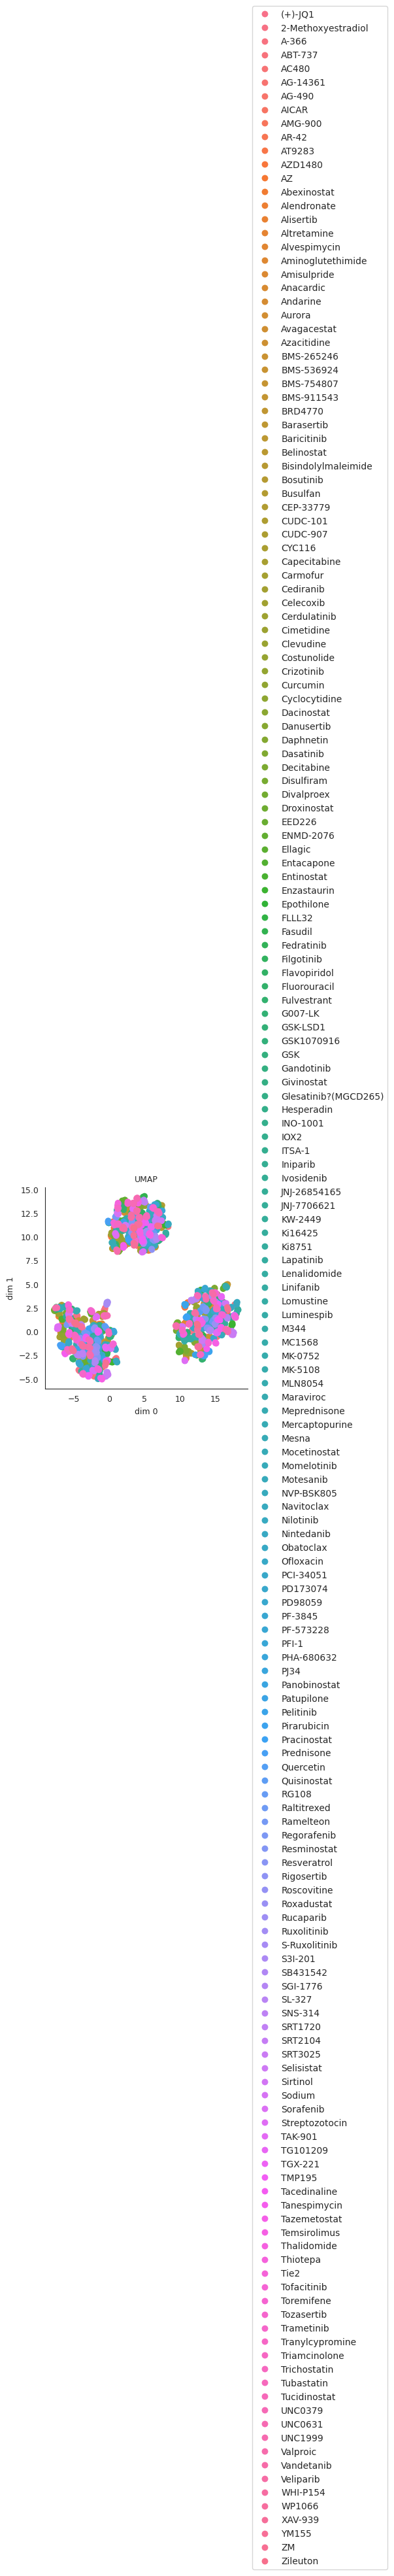

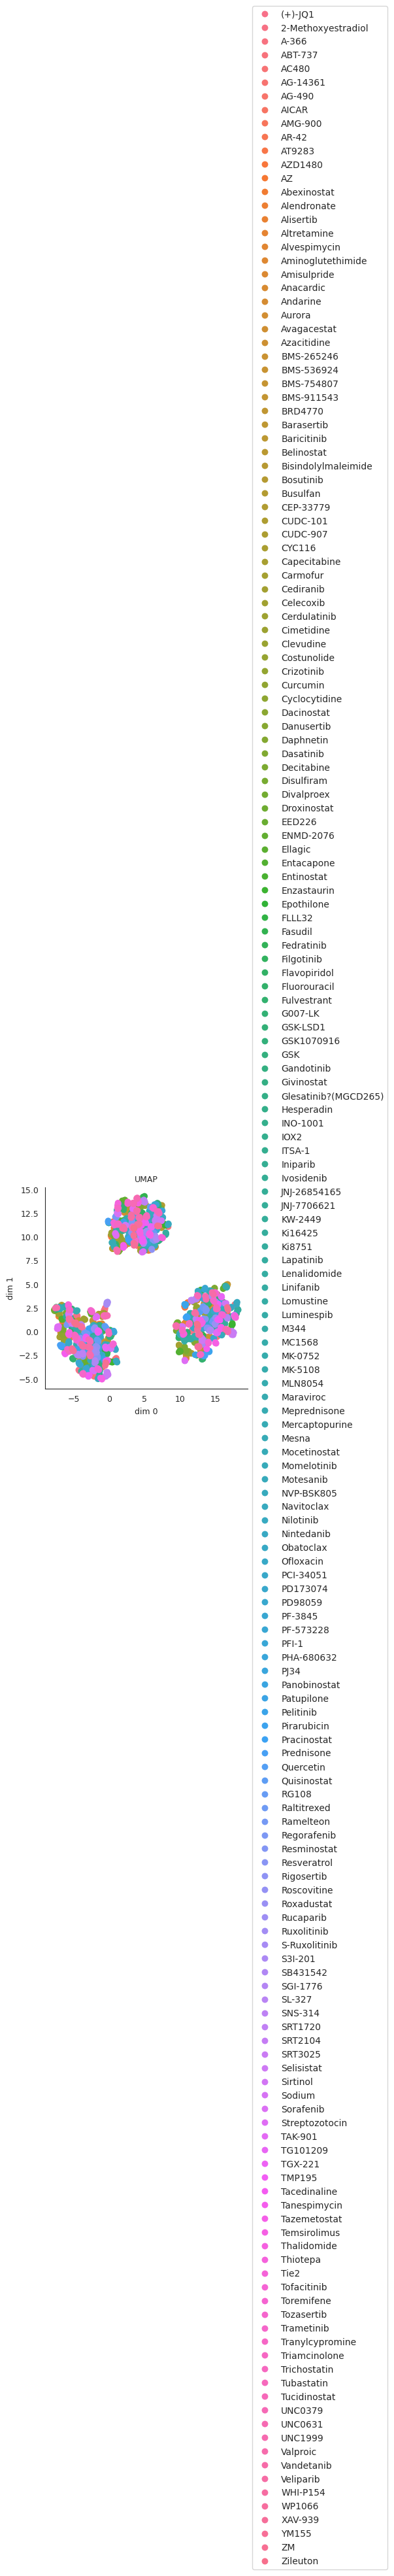

In [70]:
import cellflow
cellflow.plotting.plot_condition_embedding(df_mean_sci, embedding="UMAP", hue="drug", circle_size=50)

In [72]:
list(obs["cell_line"].unique())

['CVCL_0131',
 'CVCL_0480',
 'CVCL_0293',
 'CVCL_0397',
 'CVCL_1097',
 'CVCL_C466',
 'CVCL_0366',
 'CVCL_0099',
 'CVCL_1635',
 'CVCL_1056',
 'CVCL_0459',
 'CVCL_1547',
 'CVCL_1055',
 'CVCL_0399',
 'CVCL_1098',
 'CVCL_0504',
 'CVCL_1666',
 'CVCL_0371',
 'CVCL_1717',
 'CVCL_0152',
 'CVCL_1731',
 'CVCL_1125',
 'CVCL_1094',
 'CVCL_1550',
 'CVCL_1478',
 'CVCL_1517',
 'CVCL_0028',
 'CVCL_1285',
 'CVCL_0320',
 'CVCL_1381',
 'CVCL_0334',
 'CVCL_0179',
 'CVCL_0023',
 'CVCL_0546',
 'CVCL_1495',
 'CVCL_1119',
 'CVCL_0428',
 'CVCL_1724',
 'CVCL_0359',
 'CVCL_1716',
 'CVCL_0218',
 'CVCL_0332',
 'CVCL_0292',
 'CVCL_0069',
 'CVCL_1693',
 'CVCL_1239',
 'CVCL_1531',
 'CVCL_1577',
 'CVCL_1715',
 'CVCL_1571']

In [73]:
new_obs = obs.copy()


In [84]:
import pandas as pd

new_rows = []
constant_dose = 5.0

for drug in obs["drug"].unique():
    for cell_line in obs["cell_line"].unique():
        new_rows.append([drug, cell_line, constant_dose])

new_obs = pd.DataFrame(new_rows, columns=["drug", "cell_line", "dosage"])
new_obs["condition"] = new_obs.apply(lambda x: f"{x['drug']}_{x['dosage']}_{x['cell_line']}", axis=1)
new_obs["control"] = False

In [ ]:
df_mean_sci2, _ = cf.get_condition_embedding(_obs[sciplex_obs["drug"]!= "Vehicle"], condition_id_key="condition", rep_dict=sciplex_rep_dict)


In [85]:
df_mean2, _ = cf.get_condition_embedding(new_obs[new_obs["drug"]!= "DMSO_TF"], condition_id_key="condition", rep_dict=adata_all.uns)


[########################################] | 100% Completed | 121.90 ms
[########################################] | 100% Completed | 102.07 ms
[########################################] | 100% Completed | 3.95 sms


In [93]:
df_mean2["condition"] = df_mean2.index
df_mean2["cell_line"] = df_mean2.apply(lambda x: x["condition"].split("_")[-1], axis=1)
df_mean2["dose"] = df_mean2.apply(lambda x: x["condition"].split("_")[1], axis=1)
df_mean2["drug"] = df_mean2.apply(lambda x: x["condition"].split("_")[0], axis=1)


In [96]:
mean_drug_emb = df_mean2.groupby("drug")[np.arange(64)].mean()


/ictstr01/home/icb/dominik.klein/git_repos/cell_flow_perturbation/src/cellflow/plotting/_plotting.py:107: FutureWarning: The behavior of array concatenation with empty entries is deprecated. In a future version, this will no longer exclude empty items when determining the result dtype. To retain the old behavior, exclude the empty entries before the concat operation.
  df_processed = pd.concat((emb, df_metadata), axis=1)
/ictstr01/home/icb/dominik.klein/git_repos/cell_flow_perturbation/src/cellflow/plotting/_plotting.py:170: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc="center left", bbox_to_anchor=(1, 0.5))


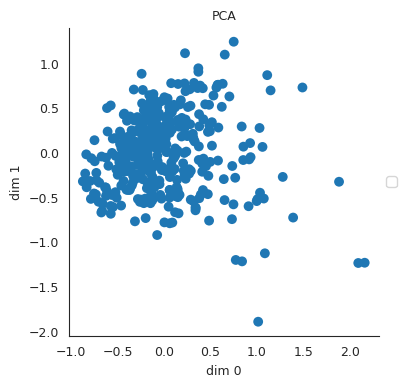

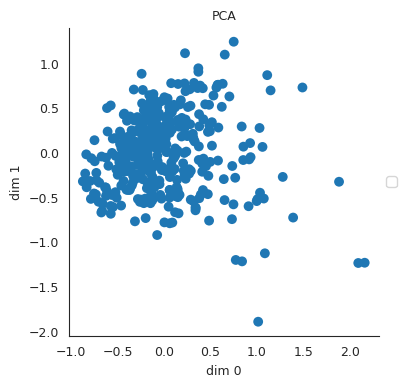

In [97]:
cellflow.plotting.plot_condition_embedding(mean_drug_emb, embedding="PCA", circle_size=50)

In [98]:
mean_drug_emb

,0,1,2,3,4,5,6,7,8,9,...,54,55,56,57,58,59,60,61,62,63
drug,,,,,,,,,,,,,,,,,,,,,
(R)-Verapamil (hydrochloride),-0.090617,0.335723,0.340246,-0.274182,-0.195509,-0.156688,-0.154013,0.068666,-0.099774,-0.027694,...,0.167736,0.014728,0.326879,-0.066005,0.010401,-0.051014,0.426640,-0.026435,0.146283,0.172590
(S)-Crizotinib,0.071614,0.363156,0.289717,-0.154739,0.330950,-0.197230,0.159039,0.057145,0.089403,-0.206335,...,-0.024914,-0.218914,0.128415,-0.061617,0.070964,-0.116978,0.248204,-0.018400,0.202882,-0.088052
18β-Glycyrrhetinic acid,0.335972,0.343454,0.088155,-0.191384,0.102506,0.074922,0.186207,0.151153,-0.119635,-0.098708,...,0.060164,-0.204847,0.131069,0.311338,0.131460,-0.133053,0.291117,-0.060571,-0.509016,-0.199055
4EGI-1,-0.058371,0.299428,0.302076,-0.105371,0.306771,-0.112721,0.169927,0.111894,0.056860,-0.076985,...,0.013709,-0.076751,-0.017883,-0.370057,0.158019,-0.073805,0.232103,-0.229767,0.281562,-0.074622
5-Azacytidine,0.087393,0.230474,0.219953,-0.167867,0.077223,-0.017726,0.106841,-0.037190,0.118505,-0.074688,...,0.006681,-0.229816,0.022114,-0.002961,0.143702,-0.268103,-0.025760,-0.021189,-0.051176,-0.076067
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
olaparib,0.108700,0.127708,0.310439,-0.112139,0.211680,-0.158062,0.083735,0.387197,-0.148120,0.105974,...,0.051928,-0.074564,0.229904,0.056088,0.122541,-0.181455,0.241454,0.032022,0.366294,0.306644
palbociclib,0.183386,0.353108,0.272566,-0.331653,0.189802,0.285197,0.228452,0.179096,0.114655,-0.065482,...,0.067306,-0.128772,0.098204,-0.117241,-0.135462,-0.034569,-0.044379,-0.145585,-0.037749,-0.202207
venetoclax,0.122624,0.380250,0.412829,-0.321747,0.272970,-0.175723,0.564598,0.377332,-0.326482,0.061995,...,-0.055614,-0.117817,0.420284,0.026309,0.242372,-0.238797,0.230458,0.056865,0.105179,0.196775


In [94]:
df_mean2.head()

,0,1,2,3,4,5,6,7,8,9,...,58,59,60,61,62,63,condition,cell_line,dose,drug
condition,,,,,,,,,,,,,,,,,,,,,
(R)-Verapamil (hydrochloride)_5.0_CVCL_0023,0.066745,0.270811,0.340731,-0.255914,-0.189675,-0.158452,-0.180162,0.001249,-0.188412,-0.002315,...,-0.017437,-0.073006,0.365663,-0.060470,0.130593,0.227092,(R)-Verapamil (hydrochloride)_5.0_CVCL_0023,0023,5.0,(R)-Verapamil (hydrochloride)
(R)-Verapamil (hydrochloride)_5.0_CVCL_0028,-0.068361,0.351727,0.263128,-0.282624,-0.246005,-0.093206,-0.085776,0.105597,-0.164505,-0.003249,...,0.058836,-0.048420,0.367956,-0.059225,0.113818,0.148476,(R)-Verapamil (hydrochloride)_5.0_CVCL_0028,0028,5.0,(R)-Verapamil (hydrochloride)
(R)-Verapamil (hydrochloride)_5.0_CVCL_0069,-0.129481,0.332286,0.364509,-0.263036,-0.205082,-0.133014,-0.138195,0.005159,-0.093102,-0.108429,...,0.011804,0.024954,0.462203,0.072786,0.133539,0.076160,(R)-Verapamil (hydrochloride)_5.0_CVCL_0069,0069,5.0,(R)-Verapamil (hydrochloride)
(R)-Verapamil (hydrochloride)_5.0_CVCL_0099,-0.066891,0.304590,0.301303,-0.236334,-0.198351,-0.238203,-0.077645,0.058668,-0.134445,-0.027627,...,0.000531,-0.069212,0.386731,0.027217,0.076054,0.201574,(R)-Verapamil (hydrochloride)_5.0_CVCL_0099,0099,5.0,(R)-Verapamil (hydrochloride)
(R)-Verapamil (hydrochloride)_5.0_CVCL_0131,-0.129249,0.355769,0.359074,-0.268705,-0.154969,-0.092374,-0.085948,0.059521,-0.067121,-0.039652,...,-0.009477,-0.063092,0.346954,-0.083618,-0.004359,0.067110,(R)-Verapamil (hydrochloride)_5.0_CVCL_0131,0131,5.0,(R)-Verapamil (hydrochloride)


In [185]:
closest_cell_line = {}
for cell_line in ["K562", "MCF7", "A549"]:
    cell_line_emb = ccle_embs_sciplex[cell_line]
    closest_emb = None
    closest_dist = np.inf
    for cl, cl_emb in ccle_embs_tahoe.items():
        print(cl, np.mean((cell_line_emb - cl_emb)**2))
        if np.mean((cell_line_emb - cl_emb)**2):
            closest_dist = np.mean((cell_line_emb - cl_emb)**2)
            closest_emb = cl
    closest_cell_line[cell_line] = closest_emb
    

CVCL_0131 2.8300680967631
CVCL_0480 2.900515022483705
CVCL_0293 2.8975904367001433
CVCL_0397 2.674459086790812
CVCL_1097 2.473649099542972
CVCL_C466 2.273858466691216
CVCL_0366 3.052300794751649
CVCL_1635 2.8641862661262065
CVCL_1056 2.4834443034634486
CVCL_0459 3.476361385805851
CVCL_1547 2.4230722690399245
CVCL_1055 2.8054119739964136
CVCL_0399 2.537683122628877
CVCL_1098 2.6475490773290646
CVCL_0504 2.592316996945734
CVCL_1666 2.3734448797365078
CVCL_0371 2.446761589705108
CVCL_1717 2.828407042677335
CVCL_0152 3.635841900244208
CVCL_1731 2.4472393782082147
CVCL_1125 2.3541931181953357
CVCL_1094 2.473649099542972
CVCL_1550 3.0260656340798513
CVCL_1478 2.4543989101451786
CVCL_1517 2.541096090232602
CVCL_1285 2.949226904625431
CVCL_0320 3.462308433044617
CVCL_1381 2.5521030077509717
CVCL_0334 2.46987516644475
CVCL_0179 2.8249036001595504
CVCL_0023 2.5668009430594183
CVCL_0546 2.5593378538207228
CVCL_1495 2.9270342272135275
CVCL_1119 2.9765396313453696
CVCL_0428 3.1278476164672067
CVCL_

In [186]:
closest_cell_line

{'K562': 'CVCL_1571', 'MCF7': 'CVCL_1571', 'A549': 'CVCL_1571'}

In [192]:
sciplex_rep_dict

{'cell_line_dict': {'A549': array([-2.98742000e+01,  1.52825470e+00,  1.13112410e+01,  1.37872970e+01,
          1.55385600e+01, -4.27754170e+01, -8.17801500e+00,  7.26889560e+00,
          1.51616940e+01,  7.84502100e+00,  8.78079300e+00, -8.98982300e+00,
         -8.77583600e+00,  2.21822810e+01,  5.21457800e+00, -5.40813200e-01,
          1.48547030e+01, -3.59697840e+01, -1.39213840e+00,  4.33293630e+00,
          1.69503600e+01,  1.09373050e+01,  3.10879020e+00,  1.41697070e+01,
          5.75857540e+00,  1.75893000e+00,  1.38740480e+00, -1.23312435e+01,
         -9.94740200e+00,  4.12120680e+00, -2.35308030e+00,  1.33686200e+01,
          5.21328350e+00,  6.41599370e+00,  3.48230800e-02, -1.44733400e+01,
          9.76734400e+00,  1.01313550e+01,  1.12112640e+00,  4.05592250e+00,
         -3.85675450e+00,  7.73613800e+00,  1.23153360e+01, -6.26408050e+00,
          1.98010180e+00, -5.83731300e+00,  6.45570400e+00,  1.38801900e+00,
          7.67890600e+00,  5.09940960e+00, -1.1083

In [194]:
for k,v in closest_cell_line.items():
    sciplex_rep_dict["cell_line_dict"][k] = ccle_embs_tahoe[v]

{'cell_line_dict': {'A549': array([-2.98742000e+01,  1.52825470e+00,  1.13112410e+01,  1.37872970e+01,
          1.55385600e+01, -4.27754170e+01, -8.17801500e+00,  7.26889560e+00,
          1.51616940e+01,  7.84502100e+00,  8.78079300e+00, -8.98982300e+00,
         -8.77583600e+00,  2.21822810e+01,  5.21457800e+00, -5.40813200e-01,
          1.48547030e+01, -3.59697840e+01, -1.39213840e+00,  4.33293630e+00,
          1.69503600e+01,  1.09373050e+01,  3.10879020e+00,  1.41697070e+01,
          5.75857540e+00,  1.75893000e+00,  1.38740480e+00, -1.23312435e+01,
         -9.94740200e+00,  4.12120680e+00, -2.35308030e+00,  1.33686200e+01,
          5.21328350e+00,  6.41599370e+00,  3.48230800e-02, -1.44733400e+01,
          9.76734400e+00,  1.01313550e+01,  1.12112640e+00,  4.05592250e+00,
         -3.85675450e+00,  7.73613800e+00,  1.23153360e+01, -6.26408050e+00,
          1.98010180e+00, -5.83731300e+00,  6.45570400e+00,  1.38801900e+00,
          7.67890600e+00,  5.09940960e+00, -1.1083